# Projeto 1 — Notebook 02 · Pré-processamento, representação e classificação de sentimento

**Do texto à decisão: sentimento e temas nas avaliações da Americanas** · CDIA · PUC-SP · 2026.2
Equipe: Matheus Campos Amorim (00361482) · *(demais integrantes no README)*

Base: B2W-Reviews01 (REAL; OSHIRO; MAFRA, 2019), CC BY-NC-SA 4.0, baixada do repositório oficial pelo notebook 01.

**O que vem do notebook 01** (`artefatos/base_auditada.parquet` e `artefatos/decisoes.json`):

* rótulo = nota binária: **1-2★ negativo, 4-5★ positivo, 3★ fora**;
* entrada = **só o texto** (`recommend_to_a_friend` proibida; título só no teste de vazamento);
* sem avaliações vazias, sem cópias de texto, sem o texto de rótulo conflitante → **110.874 avaliações**;
* **baseline da classe majoritária: 0,706**, impresso ao lado de toda acurácia.

**Como este notebook mede, para não se enganar:**

```
110.874 avaliações ─┬─ 80% TREINO ─┬─ 75% treino-ajuste ─→ ajusta vetorizador + modelo
                    │              └─ 25% VALIDAÇÃO ─────→ decide o pré-processamento e o TF-IDF
                    └─ 20% TESTE ──────────────────────────→ só no fim, uma vez por modelo final
```

Toda escolha de pré-processamento e de parâmetro é feita olhando a **validação**. O **teste** só é usado para os
números finais (representações, classificadores, vazamento, erros). O vetorizador é sempre ajustado **só** na parte
de treino da comparação.

In [1]:
# ⟦célula 02.01⟧
import importlib.util, subprocess, sys
for pacote in ["gensim", "nltk", "joblib", "pyarrow"]:
    if importlib.util.find_spec(pacote) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

import json, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import nltk
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, f1_score, recall_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

SEMENTE = 42
for pasta in ["artefatos", "figuras", "app/modelos"]:
    Path(pasta).mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
AZUL, LARANJA, CINZA, VERDE = "#2E5E8C", "#C0592B", "#9A9A9A", "#4C8C4A"
pd.set_option("display.max_colwidth", 160)
def salvar(fig, nome):
    fig.savefig(f"figuras/{nome}.png", bbox_inches="tight", dpi=150); return f"figuras/{nome}.png"

assert Path("artefatos/base_auditada.parquet").exists(), "Rode o notebook 01_auditoria antes deste."
base = pd.read_parquet("artefatos/base_auditada.parquet")
decisoes = json.loads(Path("artefatos/decisoes.json").read_text())
df = base[base["no_modelo"]].reset_index(drop=True).copy()
df["review_title"] = df["review_title"].fillna("")
BASELINE = decisoes["baseline_maioria"]
print(f"{len(df):,} avaliações no conjunto do modelo · baseline da maioria = {BASELINE:.3f}".replace(",", "."))

110.874 avaliações no conjunto do modelo · baseline da maioria = 0.706


## 1. O módulo de pré-processamento

O pipeline fica num arquivo (`app/preproc.py`) para que o **mesmo código** sirva ao notebook e ao app Streamlit:
o texto que o usuário colar no app passa exatamente pelas mesmas etapas que o treino.

Cada etapa é um parâmetro, porque cada uma vai ser **medida** nas duas opções antes de ser decidida. A lista de
stop words é a do NLTK para o português (200 formas sem acento), **menos as palavras protegidas**: negações,
intensificadores e conectivos de contraste. É a regra das `STOPWORDS_PROTEGIDAS` da disciplina: tirar `nao` de
*"não gostei"* deixa *"gostei"*.

In [2]:
%%writefile app/preproc.py
# ⟦célula 02.02⟧
"""Pré-processamento do Projeto 1 (B2W-Reviews01). Gerado pelo notebook 02, célula 02.02."""
import re, unicodedata

URL = re.compile(r"https?://\S+|www\.\S+")
EMOJI = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF\U0000FE0F]")
ESTICADA = re.compile(r"([^\W\d_])\1{2,}")          # letra repetida 3+ vezes: muuuito -> muito
SO_LETRAS = re.compile(r"[^a-zà-ÿ\s]")

# NLTK 'portuguese' (2024), sem acentos -- 200 formas
STOPWORDS_NLTK = set("""a ao aos aquela aquelas aquele aqueles aquilo as ate com como da das de dela delas dele deles
depois do dos e ela elas ele eles em entre era eram eramos essa essas esse esses esta estamos estao estar estas estava
estavam estavamos este esteja estejam estejamos estes esteve estive estivemos estiver estivera estiveram estiveramos
estiverem estivermos estivesse estivessem estivessemos estou eu foi fomos for fora foram foramos forem formos fosse
fossem fossemos fui ha haja hajam hajamos hao havemos haver hei houve houvemos houver houvera houveram houveramos
houverao houverei houverem houveremos houveria houveriam houveriamos houvermos houvesse houvessem houvessemos isso
isto ja lhe lhes mais mas me mesmo meu meus minha minhas muito na nao nas nem no nos nossa nossas nosso nossos num
numa o os ou para pela pelas pelo pelos por qual quando que quem sao se seja sejam sejamos sem ser sera serao serei
seremos seria seriam seriamos seu seus so somos sou sua suas tambem te tem temos tenha tenham tenhamos tenho tera
terao terei teremos teria teriam teriamos teu teus teve tinha tinham tinhamos tive tivemos tiver tivera tiveram
tiveramos tiverem tivermos tivesse tivessem tivessemos tu tua tuas um uma voce voces vos""".split())

# negação, intensidade e contraste: carregam sentimento e NÃO podem sair
PROTEGIDAS = {"nao", "nem", "nunca", "sem", "mas", "muito", "mais", "ja", "so", "ate", "mesmo"}
STOPWORDS = STOPWORDS_NLTK - PROTEGIDAS
MARCA_CAIXA_ALTA = "_caixa_alta_"


def sem_acento(s):
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))


def fracao_maiuscula(s):
    letras = [c for c in s if c.isalpha()]
    return sum(c.isupper() for c in letras) / len(letras) if letras else 0.0


def normalizar(texto, acentos=False, esticada=True, caixa_alta=True):
    """Texto cru -> tokens normalizados, separados por espaço (antes de stop words e stemming)."""
    texto = "" if texto is None else str(texto)
    grita = caixa_alta and len(texto) >= 10 and fracao_maiuscula(texto) >= 0.8
    s = texto.lower()
    s = URL.sub(" ", s)
    s = EMOJI.sub(" ", s)
    if not acentos:
        s = sem_acento(s)
    s = SO_LETRAS.sub(" ", s)
    if esticada:
        s = ESTICADA.sub(r"\1", s)
    tokens = s.split()
    if grita:
        tokens.append(MARCA_CAIXA_ALTA)
    return " ".join(tokens)


def tokenizar(normalizado, stop=STOPWORDS, stemmer=None):
    tokens = [t for t in normalizado.split() if sem_acento(t) not in stop] if stop else normalizado.split()
    if stemmer is not None:
        tokens = [t if t == MARCA_CAIXA_ALTA else stemmer(t) for t in tokens]
    return tokens


def preparar(texto, acentos=False, esticada=True, caixa_alta=True, remover_stop=True):
    """O pipeline completo, na configuração escolhida -- usado pelo app."""
    return " ".join(tokenizar(normalizar(texto, acentos, esticada, caixa_alta),
                              stop=STOPWORDS if remover_stop else None))

Overwriting app/preproc.py


In [3]:
# ⟦célula 02.03⟧
sys.path.insert(0, "app")
import preproc
importlib.reload(preproc)
exemplo = "NÃO RECEBI o produto!!! Péssimooo atendimento 😡 veja http://bit.ly/x 10/10"
print("cru:        ", exemplo)
print("normalizado:", preproc.normalizar(exemplo))
print("tokens:     ", preproc.tokenizar(preproc.normalizar(exemplo)))
print(f"stop words: {len(preproc.STOPWORDS_NLTK)} na lista do NLTK → {len(preproc.STOPWORDS)} depois de proteger {sorted(preproc.PROTEGIDAS)}")

cru:         NÃO RECEBI o produto!!! Péssimooo atendimento 😡 veja http://bit.ly/x 10/10
normalizado: nao recebi o produto pessimo atendimento veja
tokens:      ['nao', 'recebi', 'produto', 'pessimo', 'atendimento', 'veja']
stop words: 200 na lista do NLTK → 190 depois de proteger ['ate', 'ja', 'mais', 'mas', 'mesmo', 'muito', 'nao', 'nem', 'nunca', 'sem', 'so']


## 2. A divisão — treino, validação e teste

Estratificada pela classe, com `random_state=42`. A asserção no fim confirma que **nenhum texto do teste aparece no
treino** (a deduplicação do notebook 01 garante isso, mas é barato conferir).

In [4]:
# ⟦célula 02.04⟧
idx = np.arange(len(df))
i_treino, i_teste = train_test_split(idx, test_size=0.20, stratify=df["classe"], random_state=SEMENTE)
i_ajuste, i_valid = train_test_split(i_treino, test_size=0.25, stratify=df.loc[i_treino, "classe"], random_state=SEMENTE)
y = df["classe"].values

# baseline: a classe majoritária do TREINO, avaliada em cada partição
maioria = pd.Series(y[i_treino]).mode()[0]
BASE_VALID = (y[i_valid] == maioria).mean()
BASE_TESTE = (y[i_teste] == maioria).mean()
assert not set(df.loc[i_teste, "review_text"]) & set(df.loc[i_treino, "review_text"]), "texto do teste no treino!"

for nome, ii in [("treino (total)", i_treino), ("  treino-ajuste", i_ajuste), ("  validação", i_valid), ("teste", i_teste)]:
    print(f"{nome:16s} {len(ii):>7,} avaliações · % positivo {np.mean(y[ii] == 'positivo'):.3f}".replace(",", "."))
print(f"\nbaseline (chutar '{maioria}'): validação {BASE_VALID:.3f} · teste {BASE_TESTE:.3f}")

treino (total)    88.699 avaliações · % positivo 0.706
  treino-ajuste   66.524 avaliações · % positivo 0.706
  validação       22.175 avaliações · % positivo 0.706
teste             22.175 avaliações · % positivo 0.706

baseline (chutar 'positivo'): validação 0.706 · teste 0.706


In [5]:
# ⟦célula 02.05⟧
PLACAR = []   # toda medição entra aqui, sempre com o baseline ao lado

def medir(nome, y_true, y_pred, particao, base, extra=None):
    linha = {"modelo": nome, "partição": particao, "acurácia": accuracy_score(y_true, y_pred), "baseline": base,
             "macro-F1": f1_score(y_true, y_pred, average="macro"),
             "recall negativo": recall_score(y_true, y_pred, pos_label="negativo"),
             "recall positivo": recall_score(y_true, y_pred, pos_label="positivo")}
    if extra: linha.update(extra)
    PLACAR.append(linha)
    return linha

def tfidf_lr(docs_tr, y_tr, docs_te, ngram=(1, 1), min_df=5):
    vet = TfidfVectorizer(ngram_range=ngram, min_df=min_df, token_pattern=r"\S+", lowercase=False)
    A = vet.fit_transform(docs_tr)                 # ajusta SÓ no treino
    B = vet.transform(docs_te)                     # no outro lado, só transform
    modelo = LogisticRegression(max_iter=2000).fit(A, y_tr)
    return modelo.predict(B), vet, modelo

def na_validacao(nome, docs, ngram=(1, 1), min_df=5, extra=None):
    docs = np.asarray(docs, dtype=object)
    p, vet, _ = tfidf_lr(docs[i_ajuste], y[i_ajuste], docs[i_valid], ngram, min_df)
    return medir(nome, y[i_valid], p, "validação", BASE_VALID, {"vocabulário": len(vet.vocabulary_), **(extra or {})})
print("funções de medição prontas")

funções de medição prontas


## 3. Pré-processamento — o que cada etapa muda

### 3.1. Vocabulário, tokens e um exemplo antes/depois, etapa por etapa

Medido no **treino** (88.699 avaliações). As etapas são cumulativas, na ordem do pipeline.

In [6]:
# ⟦célula 02.06⟧
nltk.download("rslp", quiet=True)
_rslp = nltk.stem.RSLPStemmer()
_cache = {}
def stem(t):
    if t not in _cache: _cache[t] = _rslp.stem(t)
    return _cache[t]

ETAPAS_TEXTO = [
    ("0. texto cru (split por espaço)", lambda s: s),
    ("1. minúsculas",                   str.lower),
    ("2. remover URL",                  lambda s: preproc.URL.sub(" ", s)),
    ("3. remover emoji",                lambda s: preproc.EMOJI.sub(" ", s)),
    ("4. remover acentos",              preproc.sem_acento),
    ("5. só letras (sem dígito/pontuação)", lambda s: preproc.SO_LETRAS.sub(" ", s)),
    ("6. colapsar letra esticada",      lambda s: preproc.ESTICADA.sub(r"\1", s)),
]
treino_cru = df.loc[i_treino, "review_text"].tolist()
linhas, exemplos, atual = [], [], treino_cru
for nome, f in ETAPAS_TEXTO:
    novo = [f(s) for s in atual]
    mudou = next((k for k, (a, b) in enumerate(zip(atual, novo)) if a.split() != b.split()), None)
    if nome.startswith("0") or mudou is None:
        exemplos.append((nome, "", ""))
    else:
        exemplos.append((nome, atual[mudou][:110], novo[mudou][:110]))
    docs_afetados = sum(a.split() != b.split() for a, b in zip(atual, novo))
    toks = [s.split() for s in novo]
    linhas.append((nome, sum(map(len, toks)), len({t for d in toks for t in d}), docs_afetados))
    atual = novo

toks = [s.split() for s in atual]
for nome, f in [("7. remover stop words (com protegidas)", lambda d: [t for t in d if t not in preproc.STOPWORDS]),
                ("8. stemming RSLP", lambda d: [stem(t) for t in d])]:
    novos = [f(d) for d in toks]
    mudou = next(k for k, (a, b) in enumerate(zip(toks, novos)) if a != b)
    exemplos.append((nome, " ".join(toks[mudou])[:110], " ".join(novos[mudou])[:110]))
    linhas.append((nome, sum(map(len, novos)), len({t for d in novos for t in d}), sum(a != b for a, b in zip(toks, novos))))
    toks = novos

efeito = pd.DataFrame(linhas, columns=["etapa", "tokens", "vocabulário", "avaliações alteradas"])
efeito["formas colapsadas"] = (-efeito["vocabulário"].diff()).fillna(0).astype(int)
efeito["vocabulário (% do cru)"] = (efeito["vocabulário"] / efeito["vocabulário"].iloc[0] * 100).round(1)
efeito

,etapa,tokens,vocabulário,avaliações alteradas,formas colapsadas,vocabulário (% do cru)
0,0. texto cru (split por espaço),2010036,110067,0,0,100.0
1,1. minúsculas,2010036,92915,80728,17152,84.4
2,2. remover URL,2009994,92870,57,45,84.4
3,3. remover emoji,2009942,92829,77,41,84.3
4,4. remover acentos,2010028,89787,71620,3042,81.6
5,5. só letras (sem dígito/pontuação),1995023,37495,82913,52292,34.1
6,6. colapsar letra esticada,1995023,36705,1387,790,33.3
7,7. remover stop words (com protegidas),1300239,36545,86706,160,33.2
8,8. stemming RSLP,1300239,18244,88528,18301,16.6


In [7]:
# ⟦célula 02.07⟧
pd.DataFrame(exemplos, columns=["etapa", "antes", "depois"]).iloc[1:]

,etapa,antes,depois
1,1. minúsculas,"Já possuo hà algum tempo a tenda gazebo,porém até agora não tinha comprado as paredes pois não havia achado se","já possuo hà algum tempo a tenda gazebo,porém até agora não tinha comprado as paredes pois não havia achado se"
2,2. remover URL,"atende as expectativas, porém em matéria de preço e benefícios este computador aqui é melhor: http://zipvale.c","atende as expectativas, porém em matéria de preço e benefícios este computador aqui é melhor:"
3,3. remover emoji,"continuação do livro “o noivo da minha melhor amiga “ . uma história que me surpreendeu muito, pois eu não gos","continuação do livro “o noivo da minha melhor amiga “ . uma história que me surpreendeu muito, pois eu não gos"
4,4. remover acentos,"já possuo hà algum tempo a tenda gazebo,porém até agora não tinha comprado as paredes pois não havia achado se","ja possuo ha algum tempo a tenda gazebo,porem ate agora nao tinha comprado as paredes pois nao havia achado se"
5,5. só letras (sem dígito/pontuação),"ja possuo ha algum tempo a tenda gazebo,porem ate agora nao tinha comprado as paredes pois nao havia achado se",ja possuo ha algum tempo a tenda gazebo porem ate agora nao tinha comprado as paredes pois nao havia achado se
6,6. colapsar letra esticada,eles me deram o prazo de mais de dois meses para me enviar a cadeira ja passou mais de um mes que eu compr,eles me deram o prazo de mais de dois meses para me enviar a cadeira ja passou mais de um mes que eu compr
7,7. remover stop words (com protegidas),ja possuo ha algum tempo a tenda gazebo porem ate agora nao tinha comprado as paredes pois nao havia achado se,ja possuo algum tempo tenda gazebo porem ate agora nao comprado paredes pois nao havia achado separadamente co
8,8. stemming RSLP,ja possuo algum tempo tenda gazebo porem ate agora nao comprado paredes pois nao havia achado separadamente co,ja possu algum temp tend gazeb por ate agor nao compr pared poi nao hav ach separad compr agor fic perfeit enc


figuras/02_efeito_preprocessamento.png


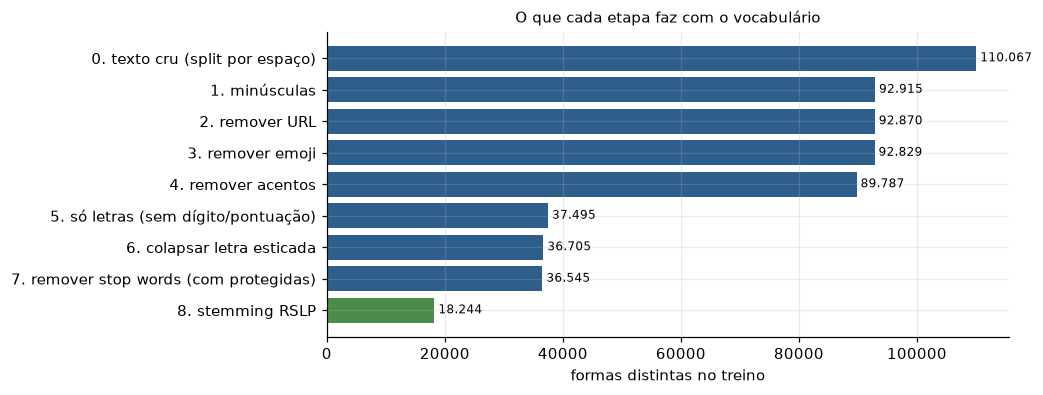

In [8]:
# ⟦célula 02.08⟧
fig, eixo = plt.subplots(figsize=(8, 3.6))
eixo.barh(efeito["etapa"][::-1], efeito["vocabulário"][::-1], color=[VERDE if "stem" in e else AZUL for e in efeito["etapa"][::-1]])
for k, v in enumerate(efeito["vocabulário"][::-1]):
    eixo.text(v, k, f" {v:,}".replace(",", "."), va="center", fontsize=8)
eixo.set_xlabel("formas distintas no treino"); eixo.set_title("O que cada etapa faz com o vocabulário", fontsize=10)
print(salvar(fig, "02_efeito_preprocessamento")); plt.show()

**Leitura da tabela** (⟦células 02.06 e 02.07⟧). De **110.067** formas no texto cru para **36.545** depois das stop
words: o pipeline apaga **2/3 do vocabulário**, e quase nada disso é das etapas "de sentimento".

* **Só letras** é a etapa que mais corta: **52.292 formas colapsadas** (de 89.787 para 37.495). Cada palavra grudada em
  pontuação (`gazebo,porém`, `rápido!!`, `produto.`) era uma forma nova. Na tabela é a etapa "chata", e é a que mais
  importa.
* **Minúsculas** colapsa 17.152 formas; **acentos**, 3.042 (`não`/`nao`, `ótimo`/`otimo` viram uma coisa só).
* **URL** (45 formas, 57 avaliações) e **emoji** (41 formas, 77 avaliações) são raros nesta base. Diferente dos tweets do
  Lab 05, avaliação de produto quase não tem link nem emoji. Decisão: remover os dois; não há volume para virar sinal.
* **Letra esticada** atinge **1.387 avaliações** e colapsa **790 formas** (`adoreiiii` → `adorei`). Confirma a auditoria:
  esticada de verdade é rara nesta base.
* **Stop words** é o espelho do Lab 05: tira **35% dos tokens** (1.995.023 → 1.300.239) e só **160 formas**. Poucas palavras
  ditas o tempo todo.
* **Stemming RSLP** faz o contrário: não tira um token e **corta o vocabulário pela metade** (36.545 → 18.244). O exemplo
  mostra o preço: `possuo → possu`, `tempo → temp`, `ficou perfeito → fic perfeit`.

### 3.2. As decisões, medidas nas duas opções (validação)

Para cada decisão, **uma coisa muda** e o resto fica na configuração de referência. Mesmo classificador (TF-IDF de
unigramas, `min_df=5`, regressão logística), mesma partição de validação.

In [9]:
# ⟦célula 02.09⟧
textos = df["review_text"].tolist()
REF = dict(acentos=False, esticada=True, caixa_alta=True)

def docs_com(stop="protegida", stemmer=None, **muda):
    cfg = {**REF, **muda}
    lista = {"protegida": preproc.STOPWORDS, "nltk completa": preproc.STOPWORDS_NLTK, "nenhuma": None}[stop]
    return [" ".join(preproc.tokenizar(preproc.normalizar(t, **cfg), stop=lista, stemmer=stemmer)) for t in textos]

t0 = time.time()
DOCS_REF = docs_com()
experimentos = [
    ("referência: sem acento · colapsa esticada · marca CAIXA ALTA · stop protegida", DOCS_REF),
    ("acentos: MANTER",                         docs_com(acentos=True)),
    ("letra esticada: PRESERVAR",               docs_com(esticada=False)),
    ("CAIXA ALTA: NÃO marcar",                  docs_com(caixa_alta=False)),
    ("stop words: NÃO remover",                 docs_com(stop="nenhuma")),
    ("stop words: lista NLTK completa (tira 'nao')", docs_com(stop="nltk completa")),
    ("stemming RSLP: APLICAR",                  docs_com(stemmer=stem)),
]
PLACAR_ANTES = len(PLACAR)
for nome, docs in experimentos:
    na_validacao(nome, docs)
decisoes_pre = pd.DataFrame(PLACAR[PLACAR_ANTES:])[["modelo", "vocabulário", "acurácia", "baseline", "macro-F1", "recall negativo"]]
print(f"({time.time() - t0:.0f} s)")
decisoes_pre.round(4)

(41 s)


,modelo,vocabulário,acurácia,baseline,macro-F1,recall negativo
0,referência: sem acento · colapsa esticada · marca CAIXA ALTA · stop protegida,8803,0.9438,0.706,0.9321,0.8989
1,acentos: MANTER,9084,0.9437,0.706,0.9320,0.8982
2,letra esticada: PRESERVAR,8827,0.9442,0.706,0.9326,0.8991
3,CAIXA ALTA: NÃO marcar,8802,0.9442,0.706,0.9325,0.8997
4,stop words: NÃO remover,8950,0.9443,0.706,0.9327,0.9000
5,stop words: lista NLTK completa (tira 'nao'),8793,0.9356,0.706,0.9220,0.8805
6,stemming RSLP: APLICAR,4748,0.9413,0.706,0.9291,0.8937


In [10]:
# ⟦célula 02.10⟧
# CAIXA ALTA e letra esticada como SINAL: o que o modelo aprendeu com eles?
p, vet, modelo = tfidf_lr(np.asarray(DOCS_REF, dtype=object)[i_ajuste], y[i_ajuste], np.asarray(DOCS_REF, dtype=object)[i_valid])
coef = pd.Series(modelo.coef_[0], index=vet.get_feature_names_out())   # > 0 puxa para 'positivo'
print(f"coeficiente de '{preproc.MARCA_CAIXA_ALTA}': {coef[preproc.MARCA_CAIXA_ALTA]:+.3f} "
      f"(posição {int((coef < coef[preproc.MARCA_CAIXA_ALTA]).sum()) + 1} de {len(coef):,} do mais negativo para o mais positivo)".replace(",", "."))

docs_esticada = np.asarray(docs_com(esticada=False), dtype=object)
p2, vet2, modelo2 = tfidf_lr(docs_esticada[i_ajuste], y[i_ajuste], docs_esticada[i_valid])
coef2 = pd.Series(modelo2.coef_[0], index=vet2.get_feature_names_out())
esticadas = [t for t in coef2.index if preproc.ESTICADA.search(t)]
print(f"\nsem colapsar, {len(esticadas)} formas esticadas sobrevivem ao min_df=5; as de maior peso:")
print(coef2[esticadas].sort_values(key=abs, ascending=False).head(10).round(2).to_dict())

coeficiente de '_caixa_alta_': -0.706 (posição 688 de 8.803 do mais negativo para o mais positivo)

sem colapsar, 26 formas esticadas sobrevivem ao min_df=5; as de maior peso:
{'ameiii': 0.83, 'amooo': 0.56, 'ameiiii': 0.49, 'kkkk': 0.48, 'kkkkk': 0.44, 'aaa': -0.32, 'kkkkkkk': -0.31, 'kkk': 0.29, 'muitooooo': 0.28, 'muitooo': 0.26}


**As decisões, com o número que as justifica** (⟦células 02.09 e 02.10⟧). Primeiro, a régua: com 22.175 avaliações de
validação e acurácia perto de 0,944, o erro padrão da acurácia é √(0,944 × 0,056 / 22.175) ≈ **0,0015**. Diferenças
menores que ~0,003 são ruído.

| decisão | as duas opções (acurácia · macro-F1 · vocabulário) | escolha | por quê |
|---|---|---|---|
| acentos | remover 0,9438 · 0,9321 · 8.803 — manter 0,9437 · 0,9320 · 9.084 | **remover** | empate; remover junta `não`/`nao` (o cliente escreve dos dois jeitos) e economiza 281 colunas |
| letra esticada | colapsar 0,9438 · 0,9321 — preservar 0,9442 · 0,9326 | **colapsar** | empate dentro do ruído. Preservada, ela até carrega sinal (`ameiii` +0,83, `amooo` +0,56), mas o sinal é o mesmo da forma curta: `amei` já é positiva. Colapsar deixa o modelo robusto a quem estica de outro jeito |
| CAIXA ALTA | marcar 0,9438 — não marcar 0,9442 | **marcar** (`_caixa_alta_`) | empate na métrica, mas o coeficiente é **−0,706** (posição 688 de 8.803 entre os mais negativos), coerente com 44,6% × 29,4% de negativas da auditoria. Quase todo o sinal já vem das palavras; a marca é barata (1 coluna) e serve à explicação no app |
| stop words | lista protegida 0,9438 — não remover 0,9443 — **NLTK completa 0,9356** | **lista protegida** | empate com "não remover", com 147 colunas a menos e temas mais limpos no notebook 03. A lista **completa** do NLTK (que tira `nao`, `nem`, `sem`, `muito`) é a **única decisão que custa de verdade**: −0,82 ponto de acurácia, −1,0 de macro-F1 e −1,8 de recall negativo. É a lição do Lab 05, agora com número maior |
| stemming RSLP | sem 0,9438 · 8.803 — com 0,9413 · 4.748 | **não aplicar** | corta o vocabulário quase pela metade e **perde 0,25 ponto** (no limite do ruído, mas na direção errada). Numa tarefa com 88 mil textos de treino, o TF-IDF não precisa da ajuda; e o stem (`perfeit`, `entreg`) piora a leitura dos temas e dos pesos |

**Configuração final do pipeline:** minúsculas → sem URL → sem emoji → sem acento → só letras → colapsa letra esticada →
marca CAIXA ALTA → remove stop words (lista NLTK menos 11 protegidas) → sem stemming.

### 3.3. Título e texto: juntos ou separados? (validação)

In [11]:
# ⟦célula 02.11⟧
CONFIG = {'acentos': False, 'esticada': True, 'caixa_alta': True, 'remover_stop': True}
docs_texto  = np.asarray([preproc.preparar(t, **CONFIG) for t in df["review_text"]], dtype=object)
docs_titulo = np.asarray([preproc.preparar(t, **CONFIG) for t in df["review_title"]], dtype=object)
docs_juntos = np.asarray([a + " " + b for a, b in zip(docs_titulo, docs_texto)], dtype=object)
PLACAR_ANTES = len(PLACAR)
for nome, d in [("só TEXTO", docs_texto), ("só TÍTULO", docs_titulo), ("TÍTULO + TEXTO", docs_juntos)]:
    na_validacao(nome, d)
pd.DataFrame(PLACAR[PLACAR_ANTES:])[["modelo", "vocabulário", "acurácia", "baseline", "macro-F1", "recall negativo"]].round(4)

,modelo,vocabulário,acurácia,baseline,macro-F1,recall negativo
0,só TEXTO,8803,0.9438,0.706,0.9321,0.8989
1,só TÍTULO,1875,0.9427,0.706,0.9295,0.8661
2,TÍTULO + TEXTO,9147,0.9636,0.706,0.9562,0.9405


Na validação, com o pipeline final (⟦célula 02.11⟧): **só texto 0,9438**, **só título 0,9427**, **título + texto 0,9636**.
O título, com **1.875 colunas** contra 8.803, classifica quase tão bem quanto o texto inteiro, e juntar os dois dá
**+2 pontos**. A decisão do notebook 01 se mantém: **o classificador aprende só o texto**. O teste de vazamento com o
modelo final está na seção 8.

---
## 4. Representação 1 — TF-IDF: `min_df` e `ngram_range` justificados (validação)

In [12]:
# ⟦célula 02.12⟧
PLACAR_ANTES = len(PLACAR)
for ng in [(1, 1), (1, 2), (1, 3)]:
    for md in [1, 2, 5, 10, 20]:
        if ng == (1, 3) and md < 5:
            continue          # trigramas com min_df baixo explodem a memória sem necessidade
        na_validacao(f"TF-IDF ngram={ng} min_df={md}", docs_texto, ngram=ng, min_df=md, extra={"ngram": str(ng), "min_df": md})
grade = pd.DataFrame(PLACAR[PLACAR_ANTES:])[["ngram", "min_df", "vocabulário", "acurácia", "baseline", "macro-F1"]]
grade.round(4)

,ngram,min_df,vocabulário,acurácia,baseline,macro-F1
0,"(1, 1)",1,31715,0.9440,0.706,0.9324
1,"(1, 1)",2,16254,0.9437,0.706,0.9320
2,"(1, 1)",5,8803,0.9438,0.706,0.9321
3,"(1, 1)",10,5622,0.9443,0.706,0.9328
4,"(1, 1)",20,3543,0.9434,0.706,0.9316
5,"(1, 2)",1,415753,0.9489,0.706,0.9384
6,"(1, 2)",2,96604,0.9502,0.706,0.9397
7,"(1, 2)",5,29970,0.9521,0.706,0.9420
8,"(1, 2)",10,14623,0.9522,0.706,0.9423
9,"(1, 2)",20,7463,0.9511,0.706,0.9409


figuras/02_grade_tfidf.png


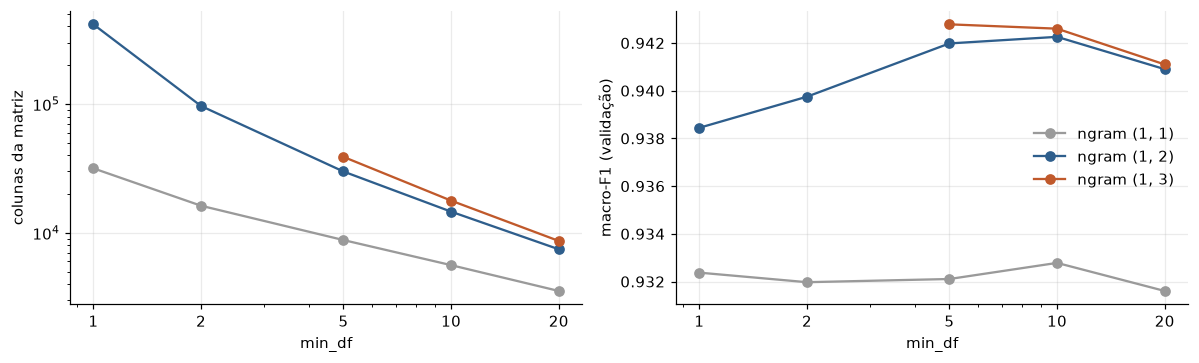

In [13]:
# ⟦célula 02.13⟧
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.4))
for ng, cor in zip(["(1, 1)", "(1, 2)", "(1, 3)"], [CINZA, AZUL, LARANJA]):
    g = grade[grade["ngram"] == ng]
    eixos[0].plot(g["min_df"], g["vocabulário"], marker="o", color=cor, label=f"ngram {ng}")
    eixos[1].plot(g["min_df"], g["macro-F1"], marker="o", color=cor, label=f"ngram {ng}")
for e in eixos: e.set_xscale("log"); e.set_xticks([1, 2, 5, 10, 20]); e.set_xticklabels([1, 2, 5, 10, 20]); e.set_xlabel("min_df")
eixos[0].set_yscale("log"); eixos[0].set_ylabel("colunas da matriz"); eixos[1].set_ylabel("macro-F1 (validação)")
eixos[1].legend(frameon=False); fig.tight_layout(); print(salvar(fig, "02_grade_tfidf")); plt.show()

**Escolha do TF-IDF** (⟦células 02.12 e 02.13⟧): **`ngram_range=(1, 2)` e `min_df=10`**.

* **Bigramas valem a pena:** de 0,9443 (unigramas, `min_df=10`) para **0,9522**, +0,8 ponto, quatro vezes o erro padrão.
  É o ganho que o Lab 05 previa: `nao recomendo`, `nao gostei`, `nao funciona` e `muito bom` passam a ser colunas
  próprias, e a negação deixa de ser só "houve um *não* no texto". Os pesos da ⟦célula 02.22⟧ confirmam: `nao recomendo`
  (−10,5) e `nao gostei` (−6,3) estão entre os três termos mais negativos.
* **Trigramas não pagam o custo:** 0,9525 contra 0,9522, com mais colunas. Dentro do ruído.
* **`min_df=10` em vez de 5:** mesmo macro-F1 (0,9423 × 0,9420) com **metade das colunas** (14.623 × 29.970). `min_df=1`
  é o pior dos três: 415.753 colunas, a maioria de termos vistos uma vez, e **macro-F1 menor** (0,9384). Coluna que um
  documento só preenche não separa nada; só custa memória e induz sobreajuste.

---
## 5. Representação 2 — Word2Vec treinado no próprio corpus (só no treino)

`vector_size=100`, `window=5`, `min_count=5`, CBOW (`sg=0`), `epochs=10`, **`seed=42` e `workers=1`** para o
resultado ser reproduzível. Treinado **só nas 88.699 avaliações de treino**: treinar no corpus inteiro faria as
palavras do teste entrarem na geometria (o vazamento da Tarefa 6.3 do Lab 05). Cada avaliação vira a **média** dos
vetores das suas palavras; avaliação sem palavra conhecida vira vetor de zeros.

In [14]:
# ⟦célula 02.14⟧
frases = [d.split() for d in docs_texto]
t0 = time.time()
w2v = Word2Vec([frases[i] for i in i_treino], vector_size=100, window=5, min_count=5,
               sg=0, epochs=10, seed=SEMENTE, workers=1)
print(f"{len(w2v.wv):,} palavras no vocabulário · 100 dimensões · {time.time() - t0:.0f} s".replace(",", "."))

def vizinhos(*palavras):
    return pd.DataFrame({p: [f"{w} ({s:.2f})" for w, s in w2v.wv.most_similar(p, topn=6)]
                         for p in palavras if p in w2v.wv}, index=[f"{i}º" for i in range(1, 7)])
vizinhos("bom", "ruim", "entrega", "atraso", "defeito", "recomendo")

10.471 palavras no vocabulário · 100 dimensões · 11 s


,bom,ruim,entrega,atraso,defeito,recomendo
1º,otimo (0.72),horrivel (0.64),entregue (0.62),atrasou (0.74),estragado (0.72),indico (0.87)
2º,excelente (0.64),pessimo (0.64),entregar (0.62),atrasado (0.72),problema (0.68),recomento (0.81)
3º,gostei (0.57),fraco (0.64),entregou (0.60),atrasada (0.69),quebrado (0.62),recomendado (0.66)
4º,exelente (0.57),fraca (0.61),chegada (0.60),previsao (0.65),estragada (0.57),recomendaria (0.63)
5º,razoavel (0.54),baixa (0.59),envio (0.58),greve (0.65),defeitos (0.56),recomendavel (0.58)
6º,satisfatorio (0.54),presta (0.56),chegar (0.56),aguardei (0.62),queimada (0.56),indicaria (0.58)


In [15]:
# ⟦célula 02.15⟧
# a régua da Tarefa 5.3: quanto vale um cosseno qualquer neste modelo?
rng = np.random.default_rng(SEMENTE)
vocab = w2v.wv.index_to_key
pares = rng.choice(len(vocab), size=(2000, 2))
ao_acaso = np.array([w2v.wv.similarity(vocab[a], vocab[b]) for a, b in pares if a != b])
print(f"cosseno entre duas palavras QUAISQUER: média {ao_acaso.mean():.3f} · percentil 95 {np.percentile(ao_acaso, 95):.3f}")
for a, b in [("bom", "ruim"), ("otimo", "pessimo"), ("entrega", "prazo"), ("recomendo", "nao")]:
    print(f"cos({a}, {b}) = {w2v.wv.similarity(a, b):.3f}")

cosseno entre duas palavras QUAISQUER: média 0.243 · percentil 95 0.571
cos(bom, ruim) = 0.343
cos(otimo, pessimo) = 0.164
cos(entrega, prazo) = 0.189
cos(recomendo, nao) = -0.142


In [16]:
# ⟦célula 02.16⟧
def vetor_doc(tokens):
    v = [w2v.wv[t] for t in tokens if t in w2v.wv]
    return np.mean(v, axis=0) if v else np.zeros(100)
D = np.vstack([vetor_doc(f) for f in frases])
vazios = int((np.abs(D[i_teste]).sum(axis=1) == 0).sum())
print(f"matriz {D.shape} · avaliações de teste sem nenhuma palavra conhecida: {vazios}")

matriz (110874, 100) · avaliações de teste sem nenhuma palavra conhecida: 33


**O que o Word2Vec aprendeu** (⟦células 02.14 a 02.16⟧). Os vizinhos convencem: `recomendo → indico (0,87)` e
`recomento (0,81)` (erro de digitação que o modelo descobriu sozinho), `atraso → atrasou, previsao, greve (0,65)` (a greve
dos caminhoneiros de maio de 2018 aparece na base), `defeito → estragado, quebrado, queimada`.

E a régua do Lab 05 se repete com outros números: duas palavras quaisquer têm cosseno médio **0,243** e percentil 95
**0,571**. `cos(bom, ruim) = 0,343` está **acima da média e abaixo do percentil 95**: semelhança de uso, não de sentido.
Aqui ela é bem menor que nos tweets (0,62), e a razão é o corpus: avaliação de produto tem contextos mais polarizados
(*"produto ruim, não recomendo"* × *"produto bom, recomendo"*) do que tweet. Ainda assim, `bom` e `ruim` não são opostos
para o modelo: ele nunca recebeu polaridade. Só **33 avaliações de teste** ficam sem nenhuma palavra conhecida
(vetor de zeros).

---
## 6. A comparação no TESTE — duas representações, mesmo classificador

A partir daqui o modelo é ajustado no **treino inteiro** (ajuste + validação, 88.699 avaliações) e medido **uma vez**
no teste (22.175). Mesma partição, mesmo classificador (regressão logística, `max_iter=2000`), mesmos tokens: **só
muda a representação**.

In [17]:
# ⟦célula 02.17⟧
NGRAM, MIN_DF = (1, 2), 10
t0 = time.time()
p_tfidf, VET, LR = tfidf_lr(docs_texto[i_treino], y[i_treino], docs_texto[i_teste], ngram=NGRAM, min_df=MIN_DF)
medir(f"TF-IDF {NGRAM} min_df={MIN_DF} + reg. logística", y[i_teste], p_tfidf, "teste", BASE_TESTE,
      {"colunas": len(VET.vocabulary_)})

lr_w2v = LogisticRegression(max_iter=2000).fit(D[i_treino], y[i_treino])
p_w2v = lr_w2v.predict(D[i_teste])
medir("Word2Vec (média) + reg. logística", y[i_teste], p_w2v, "teste", BASE_TESTE, {"colunas": 100})

print(f"({time.time() - t0:.0f} s)")
comp = pd.DataFrame(PLACAR[-2:])[["modelo", "colunas", "acurácia", "baseline", "macro-F1", "recall negativo", "recall positivo"]]
comp.round(4)

(4 s)


,modelo,colunas,acurácia,baseline,macro-F1,recall negativo,recall positivo
0,"TF-IDF (1, 2) min_df=10 + reg. logística",18913,0.9529,0.706,0.9431,0.9138,0.9692
1,Word2Vec (média) + reg. logística,100,0.9353,0.706,0.9221,0.8899,0.9543


**TF-IDF venceu, de novo** (⟦célula 02.17⟧). Mesma partição, mesmo classificador, mesmos tokens:

| representação | colunas | acurácia (baseline 0,706) | macro-F1 | recall negativo |
|---|---|---|---|---|
| TF-IDF (1,2), `min_df=10` | 18.913 | **0,9529** | **0,9431** | **0,9138** |
| Word2Vec, média | 100 | 0,9353 | 0,9221 | 0,8899 |

A diferença de **1,8 ponto** de acurácia é doze vezes o erro padrão. É a mesma conclusão do Lab 05 (0,752 × 0,726 nos
tweets), numa base em que as duas representações vão muito melhor: **embedding não é upgrade de TF-IDF**. A média de
vetores apaga a ordem *e* a negação (`nao recomendo` e `recomendo nao` dão o mesmo vetor), e o bigrama `nao recomendo`
é, sozinho, o segundo termo mais negativo do TF-IDF. O Word2Vec compra 189 vezes menos colunas, o que só seria
decisivo se memória fosse o gargalo, e não é.

---
## 7. Dois classificadores (mais um) — léxico da equipe, regressão logística e Naive Bayes

### 7.1. O léxico escrito pela equipe

Sem aprendizado nenhum: duas listas de palavras (já normalizadas, sem acento) e uma regra de negação — uma palavra
precedida, a até três tokens, por `nao`, `nem`, `nunca`, `sem` ou `nenhum` troca de sinal. Saldo > 0 → positivo,
saldo < 0 → negativo, saldo 0 → **não opina** (para a métrica, cai na classe majoritária).

In [18]:
# ⟦célula 02.18⟧
LEX_POS = set('''bom boa bons boas otimo otima otimos otimas excelente excelentes perfeito perfeita perfeitamente
maravilhoso maravilhosa recomendo adorei amei gostei lindo linda lindos lindas satisfeito satisfeita satisfeitos
rapido rapida rapidez top show eficiente confortavel pratico pratica bonito bonita incrivel parabens superou facil
util agil pontual feliz encantada encantado vale atendeu cumpre funciona'''.split())
LEX_NEG = set('''ruim pessimo pessima horrivel defeito defeituoso defeituosa quebrado quebrada quebrou decepcao
decepcionado decepcionada decepcionante lixo fraco fraca atraso atrasou atrasado atrasada demora demorou problema
problemas errado errada falso falsa enganosa enganoso reclamacao cancelar cancelado cancelamento devolver devolucao
pior arrependido arrependida absurdo descaso vergonha porcaria frustrado frustrada ridiculo pessimos'''.split())
NEGADORES = {"nao", "nem", "nunca", "sem", "nenhum", "nenhuma"}
FRASES_NEG = ["nao recebi", "nao chegou", "nao veio", "ainda nao", "nao entregue", "nao foi entregue"]

def lexico(doc_normalizado):
    toks = doc_normalizado.split()
    saldo = 0
    for k, t in enumerate(toks):
        valor = 1 if t in LEX_POS else -1 if t in LEX_NEG else 0
        if valor and any(x in NEGADORES for x in toks[max(0, k - 3):k]):
            valor = -valor
        saldo += valor
    saldo -= 2 * sum(f in doc_normalizado for f in FRASES_NEG)
    return saldo

# o léxico lê o texto NORMALIZADO sem remover stop words (precisa ver 'nao recebi', 'ainda nao')
NORM_CFG = {k: v for k, v in CONFIG.items() if k != "remover_stop"}
normal_teste = [preproc.normalizar(t, **NORM_CFG) for t in df.loc[i_teste, "review_text"]]
saldo = np.array([lexico(d) for d in normal_teste])
p_lex = np.where(saldo > 0, "positivo", np.where(saldo < 0, "negativo", maioria))
opina = saldo != 0
medir("Léxico da equipe (empate → maioria)", y[i_teste], p_lex, "teste", BASE_TESTE,
      {"colunas": len(LEX_POS) + len(LEX_NEG)})
print(f"o léxico opina em {opina.mean():.1%} do teste; onde opina, acerta {(p_lex[opina] == y[i_teste][opina]).mean():.3f}")
print(f"tamanho do léxico: {len(LEX_POS)} positivas · {len(LEX_NEG)} negativas · {len(FRASES_NEG)} frases negativas")

o léxico opina em 81.3% do teste; onde opina, acerta 0.947
tamanho do léxico: 51 positivas · 48 negativas · 6 frases negativas


In [19]:
# ⟦célula 02.19⟧
A_tr = VET.transform(docs_texto[i_treino]); A_te = VET.transform(docs_texto[i_teste])
nb_modelo = MultinomialNB().fit(A_tr, y[i_treino])
p_nb = nb_modelo.predict(A_te)
medir(f"TF-IDF {NGRAM} + Naive Bayes multinomial", y[i_teste], p_nb, "teste", BASE_TESTE, {"colunas": len(VET.vocabulary_)})

finais = pd.DataFrame([r for r in PLACAR if r["partição"] == "teste"])
finais[["modelo", "colunas", "acurácia", "baseline", "macro-F1", "recall negativo", "recall positivo"]].round(4)

,modelo,colunas,acurácia,baseline,macro-F1,recall negativo,recall positivo
0,"TF-IDF (1, 2) min_df=10 + reg. logística",18913,0.9529,0.706,0.9431,0.9138,0.9692
1,Word2Vec (média) + reg. logística,100,0.9353,0.706,0.9221,0.8899,0.9543
2,Léxico da equipe (empate → maioria),99,0.8605,0.706,0.8097,0.5847,0.9753
3,"TF-IDF (1, 2) + Naive Bayes multinomial",18913,0.9433,0.706,0.9323,0.9173,0.9541


In [20]:
# ⟦célula 02.20⟧
for nome, p in [("Léxico da equipe", p_lex), ("Naive Bayes", p_nb), ("Regressão logística (TF-IDF)", p_tfidf)]:
    print(f"=== {nome}  ·  baseline da maioria no teste = {BASE_TESTE:.3f}")
    print(classification_report(y[i_teste], p, digits=3))

=== Léxico da equipe  ·  baseline da maioria no teste = 0.706
              precision    recall  f1-score   support

    negativo      0.908     0.585     0.711      6520
    positivo      0.849     0.975     0.908     15655

    accuracy                          0.860     22175
   macro avg      0.879     0.780     0.810     22175
weighted avg      0.867     0.860     0.850     22175

=== Naive Bayes  ·  baseline da maioria no teste = 0.706
              precision    recall  f1-score   support

    negativo      0.893     0.917     0.905      6520
    positivo      0.965     0.954     0.960     15655

    accuracy                          0.943     22175
   macro avg      0.929     0.936     0.932     22175
weighted avg      0.944     0.943     0.944     22175

=== Regressão logística (TF-IDF)  ·  baseline da maioria no teste = 0.706
              precision    recall  f1-score   support

    negativo      0.925     0.914     0.919      6520
    positivo      0.964     0.969     0.967 

figuras/02_matrizes_confusao.png


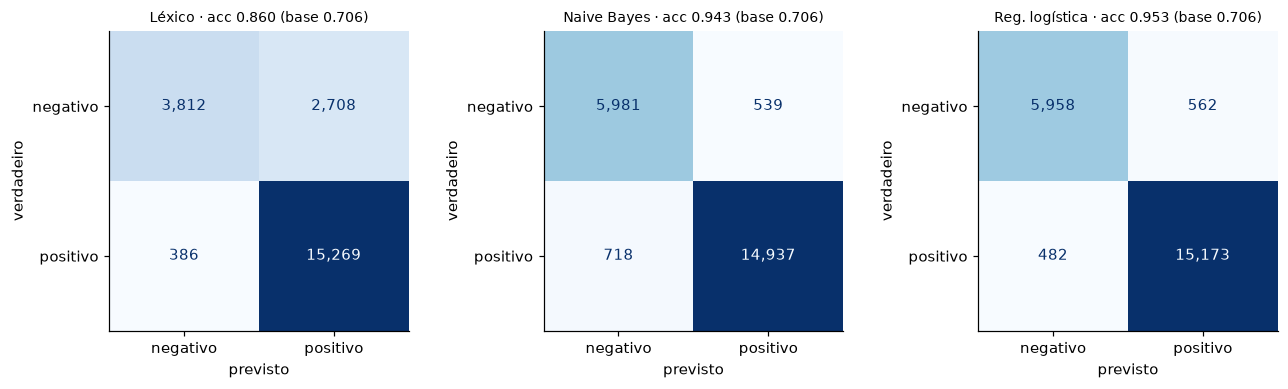

In [21]:
# ⟦célula 02.21⟧
fig, eixos = plt.subplots(1, 3, figsize=(12, 3.6))
for eixo, (nome, p) in zip(eixos, [("Léxico", p_lex), ("Naive Bayes", p_nb), ("Reg. logística", p_tfidf)]):
    ConfusionMatrixDisplay(confusion_matrix(y[i_teste], p, labels=["negativo", "positivo"]),
                           display_labels=["negativo", "positivo"]).plot(ax=eixo, cmap="Blues", colorbar=False, values_format=",d")
    eixo.set_title(f"{nome} · acc {accuracy_score(y[i_teste], p):.3f} (base {BASE_TESTE:.3f})", fontsize=9)
    eixo.grid(False); eixo.set_xlabel("previsto"); eixo.set_ylabel("verdadeiro")
fig.tight_layout(); print(salvar(fig, "02_matrizes_confusao")); plt.show()

In [22]:
# ⟦célula 02.22⟧
coef = pd.Series(LR.coef_[0], index=VET.get_feature_names_out())
pesos = pd.DataFrame({"puxam para NEGATIVO": coef.nsmallest(20).index, "peso (−)": coef.nsmallest(20).values.round(2),
                      "puxam para POSITIVO": coef.nlargest(20).index, "peso (+)": coef.nlargest(20).values.round(2)})
pesos

,puxam para NEGATIVO,peso (−),puxam para POSITIVO,peso (+)
0,nao,-11.22,excelente,13.16
1,nao recomendo,-10.49,otimo,12.10
2,nao gostei,-6.27,recomendo,10.74
3,pessimo,-5.83,muito bom,9.45
4,ruim,-5.80,otima,8.80
5,veio,-5.27,gostei,7.15
6,horrivel,-5.18,adorei,6.98
7,pessima,-5.17,bom,6.92
8,fraco,-5.02,amei,6.70
9,nao funciona,-4.74,perfeito,6.52


**Os três classificadores** (⟦células 02.18 a 02.22⟧), todos no mesmo teste, com o baseline ao lado:

| classificador | acurácia (baseline 0,706) | macro-F1 | recall negativo | recall positivo |
|---|---|---|---|---|
| Léxico da equipe (99 palavras + negação) | 0,8605 | 0,8097 | **0,5847** | 0,9753 |
| Naive Bayes multinomial (TF-IDF) | 0,9433 | 0,9323 | 0,9173 | 0,9541 |
| **Regressão logística (TF-IDF)** | **0,9529** | **0,9431** | 0,9138 | **0,9692** |

* **O léxico** é honesto e interpretável, e mostra onde está a dificuldade: onde opina (81,3% do teste) acerta **0,947**,
  quase como os modelos. O problema é o que ele **não** cobre: reclamação sem palavra de reclamação (*"veio o modelo
  errado"*, *"o cabo solta"*). Os 18,7% de empate caem na maioria (positivo), e o recall negativo despenca para 0,585.
  O cliente que reclama descreve o problema; o que elogia usa adjetivo.
* **Naive Bayes** tem o maior recall negativo (0,917) e paga com o positivo (0,954): ele erra mais na direção do alarme.
* **A regressão logística é o melhor modelo** pelo macro-F1 e é a que segue para o app.
* **Os pesos** (⟦célula 02.22⟧) são legíveis e conversam com a auditoria: `nao recomendo`, `nao gostei`, `nao funciona`,
  `nao recebi`, `devolucao`, `dinheiro`, `fragil` e `veio` puxam para negativo. `veio` é interessante: é a palavra de
  quem conta o que **chegou** (*"veio quebrado"*, *"veio errado"*, *"veio faltando peça"*), e é o tema logístico que o
  notebook 03 vai encontrar.

---
## 8. Teste de vazamento pelo título — no teste, com o modelo final

O mesmo pipeline, o mesmo TF-IDF, a mesma regressão logística, a mesma partição. Só muda **a coluna de entrada**.

In [23]:
# ⟦célula 02.23⟧
PLACAR_ANTES = len(PLACAR)
for nome, d in [("sem título (só TEXTO)", docs_texto), ("com título (TÍTULO + TEXTO)", docs_juntos), ("só TÍTULO", docs_titulo)]:
    p, v, _ = tfidf_lr(d[i_treino], y[i_treino], d[i_teste], ngram=NGRAM, min_df=MIN_DF)
    medir(f"vazamento · {nome}", y[i_teste], p, "teste", BASE_TESTE, {"colunas": len(v.vocabulary_)})
vaz = pd.DataFrame(PLACAR[PLACAR_ANTES:])[["modelo", "acurácia", "baseline", "macro-F1", "recall negativo", "recall positivo"]]
vaz["erros no teste"] = ((1 - vaz["acurácia"]) * len(i_teste)).round().astype(int)
vaz.round(4)

,modelo,acurácia,baseline,macro-F1,recall negativo,recall positivo,erros no teste
0,vazamento · sem título (só TEXTO),0.9529,0.706,0.9431,0.9138,0.9692,1044
1,vazamento · com título (TÍTULO + TEXTO),0.9699,0.706,0.9637,0.9475,0.9792,667
2,vazamento · só TÍTULO,0.9451,0.706,0.9322,0.8658,0.9782,1217


In [24]:
# ⟦célula 02.24⟧
# onde o título mais ajuda: avaliações curtas? (erros do modelo SEM título que o modelo COM título acerta)
p_sem = tfidf_lr(docs_texto[i_treino], y[i_treino], docs_texto[i_teste], NGRAM, MIN_DF)[0]
p_com = tfidf_lr(docs_juntos[i_treino], y[i_treino], docs_juntos[i_teste], NGRAM, MIN_DF)[0]
corrigidos = (p_sem != y[i_teste]) & (p_com == y[i_teste])
amostra_corr = df.loc[i_teste[corrigidos], ["review_title", "review_text", "overall_rating"]].sample(6, random_state=SEMENTE)
print(f"o título corrige {corrigidos.sum()} erros e cria {((p_sem == y[i_teste]) & (p_com != y[i_teste])).sum()}")
amostra_corr

o título corrige 465 erros e cria 88


,review_title,review_text,overall_rating
103196,Nao chegou,Quando ele conseguir chegar aqui em casa eu avalio,2
53644,Amei muito este produto!!,"No primeiro impacto fiquei decepcionada, porque a escova menor não é rotativa, Mas depois q experimentei, me apaixonei !!",5
24556,gostei,para quem não tem paciência para passar roupa é uma boa!,5
72212,Não aquece no 127w,A minha necessidade seria usar no 127w pois em casa é essa voltagem.,2
108345,gostei muito,o melhor da categoria não fica devendo nada ao concorrente,5
22966,MATERIAL ÓTIMO,"Produto maravilhoso, porém, não chegou com 5 volumes, mas sim com 3 volumes e ficou peças de montagem faltantes.",5


**O teste de vazamento** (⟦células 02.23 e 02.24⟧), com o modelo final, no teste:

| entrada | acurácia (baseline 0,706) | macro-F1 | erros em 22.175 |
|---|---|---|---|
| só texto | 0,9529 | 0,9431 | 1.044 |
| **título + texto** | **0,9699** | **0,9637** | **667** |
| só título | 0,9451 | 0,9322 | 1.217 |

**Juntar o título derruba o erro em 36%** (1.044 → 667): ele corrige 465 erros e cria 88. E o título sozinho, com
duas ou três palavras, fica a **0,8 ponto** do texto inteiro.

**Por que isso é vazamento, e não "mais informação":** o título foi escrito **depois** de o cliente decidir a nota, no mesmo
formulário, e na maior parte dos casos é a nota por extenso (*"muito bom"*, *"excelente"*, *"não recebi o produto"*). A
amostra da ⟦célula 02.24⟧ mostra o mecanismo: o texto *"Quando ele conseguir chegar aqui em casa eu avalio"* é ambíguo,
e o título *"Nao chegou"* resolve; *"para quem não tem paciência para passar roupa é uma boa!"* confunde o modelo pelo
`nao`, e o título *"gostei"* desfaz a dúvida. O título não ensina o modelo a ler melhor, ele **entrega a resposta**.

**Consequência prática:** o número que vale para o projeto é **0,953**, e não 0,970. Um modelo com título só funcionaria
onde o cliente já resumiu a própria opinião; o uso de negócio (classificar comentário de rede social, chamado de SAC,
texto livre) **não tem título**. Reportar 0,970 seria repetir o 0,990 do `:)` do Lab 05 em escala menor.

---
## 9. E se a classe neutra existisse? (experimento de confirmação)

O notebook 01 tirou as 3★ com dois números (88,5% recomendam; recall do neutro 0,192 num modelo simples). Aqui o
mesmo pipeline final roda em **três classes**, com e sem `class_weight="balanced"` — a tentativa mais barata de
fazer o modelo enxergar a classe pequena. Divisão estratificada própria (80/20, semente 42), porque o conjunto é outro.

In [25]:
# ⟦célula 02.25⟧
d3 = base[base["no_modelo_3"]].reset_index(drop=True)
docs3 = np.asarray([preproc.preparar(t, **CONFIG) for t in d3["review_text"]], dtype=object)
y3 = d3["classe3"].values
j_tr, j_te = train_test_split(np.arange(len(d3)), test_size=0.2, stratify=y3, random_state=SEMENTE)
base3 = (y3[j_te] == pd.Series(y3[j_tr]).mode()[0]).mean()
v3 = TfidfVectorizer(ngram_range=NGRAM, min_df=MIN_DF, token_pattern=r"\S+", lowercase=False)
A3, B3 = v3.fit_transform(docs3[j_tr]), v3.transform(docs3[j_te])
linhas3 = []
for nome, peso in [("3 classes", None), ("3 classes, class_weight='balanced'", "balanced")]:
    p3 = LogisticRegression(max_iter=2000, class_weight=peso).fit(A3, y3[j_tr]).predict(B3)
    r = recall_score(y3[j_te], p3, average=None, labels=["negativo", "neutro", "positivo"])
    linhas3.append((nome, accuracy_score(y3[j_te], p3), base3, f1_score(y3[j_te], p3, average="macro"), *r))
    if peso: p3_bal = p3
tres = pd.DataFrame(linhas3, columns=["modelo", "acurácia", "baseline", "macro-F1", "recall neg", "recall NEUTRO", "recall pos"])
print(f"{len(d3):,} avaliações · % neutro {np.mean(y3 == 'neutro'):.1%}".replace(",", "."))
display(tres.round(3))
pd.crosstab(pd.Series(y3[j_te], name="verdadeiro"), pd.Series(p3_bal, name="previsto (balanced)"), normalize="index").round(3)

126.723 avaliações · % neutro 12.5%


,modelo,acurácia,baseline,macro-F1,recall neg,recall NEUTRO,recall pos
0,3 classes,0.844,0.618,0.699,0.903,0.228,0.945
1,"3 classes, class_weight='balanced'",0.792,0.618,0.719,0.877,0.567,0.802


previsto (balanced),negativo,neutro,positivo
verdadeiro,,,
negativo,0.877,0.104,0.019
neutro,0.175,0.567,0.258
positivo,0.031,0.167,0.802


**Vale manter o neutro? Não, e agora com o pipeline completo** (⟦célula 02.25⟧):

| modelo (3 classes, 126.723 avaliações) | acurácia (baseline 0,618) | macro-F1 | recall neg | **recall neutro** | recall pos |
|---|---|---|---|---|---|
| regressão logística | 0,844 | 0,699 | 0,903 | **0,228** | 0,945 |
| com `class_weight="balanced"` | 0,791 | 0,718 | 0,877 | **0,565** | 0,801 |

Sem ajuste, o neutro tem recall **0,228**: igual ao do notebook 01 (0,192) e ao do enunciado (0,195), mesmo com bigramas e
pipeline completo. Com pesos de classe ele sobe para **0,565**, mas o preço é alto: o recall positivo cai **14 pontos**, a
acurácia cai 5, e a matriz mostra para onde vão os erros. **26% dos neutros são lidos como positivos e 17% como
negativos**, e 17% dos positivos passam a ser chamados de neutros. O "neutro" não é uma região do texto: é uma mistura
de "bom com ressalva" (88,5% recomendam) e "ruim com atenuante". Mantê-lo empioraria as duas classes que importam para
negócio para acertar meia classe que não tem uso claro. **Decisão confirmada: binário, 3★ fora.**

---
## 10. Dez erros do melhor modelo, lidos um a um

Melhor modelo: **TF-IDF + regressão logística** (maior macro-F1 no teste, ⟦célula 02.17⟧). "Positivo" é a classe
positiva, então:

* **falso positivo** = o modelo disse *positivo* e a nota era 1-2★;
* **falso negativo** = o modelo disse *negativo* e a nota era 4-5★.

Cinco de cada, **sorteados** entre os erros (semente 42) para serem representativos, e não os mais extremos. A
recomendação e o título aparecem só para a leitura — o modelo não os viu.

In [26]:
# ⟦célula 02.26⟧
proba_pos = LR.predict_proba(VET.transform(docs_texto[i_teste]))[:, list(LR.classes_).index("positivo")]
teste = df.loc[i_teste, ["review_title", "review_text", "overall_rating", "recommend_to_a_friend", "site_category_lv1"]].copy()
teste["previsto"], teste["P(positivo)"] = p_tfidf, proba_pos.round(3)
fp = teste[(teste["previsto"] == "positivo") & (y[i_teste] == "negativo")]
fn = teste[(teste["previsto"] == "negativo") & (y[i_teste] == "positivo")]
print(f"falsos positivos: {len(fp):,} · falsos negativos: {len(fn):,}".replace(",", "."))
fp5 = fp.sample(5, random_state=SEMENTE); fn5 = fn.sample(5, random_state=SEMENTE)
fp5.assign(caso=[f"FP{k}" for k in range(1, 6)]).set_index("caso")

falsos positivos: 562 · falsos negativos: 482


,review_title,review_text,overall_rating,recommend_to_a_friend,site_category_lv1,previsto,P(positivo)
caso,,,,,,,
FP1,PRECISO VER MANUAL PARA SABER SE E FACIL USA-LO,"QUERO MUITO COMPRAR POR SER DA MORMAII, MAS NAO ENCONTREI NA INTERNET O MANUAL, SO ASSIM IREI CERTIFICAR SE É FACIL O USO.",2,Yes,Miscellaneous,positivo,0.814
FP2,Pré venda = lixo,"Essa pré venda da americanas deve ser para entregar um outro God of War, onde o Atreus já está adulto e casado, o melhor é que eles nem respondem é vácuo et...",1,Yes,Games,positivo,0.689
FP3,O produto veio com defeito!,"Minha prima comprou uma pelo mesmo site e a dela é ótima, quando eu resolvi comprar Vi comentários dizendo que o produto não era muito bom mesmo assim com...",1,No,Beleza e Perfumaria,positivo,0.708
FP4,Tinta descasca fácil.,"Elas são até bonitas e funcionais, mas a tinta descasca muito fácil. Só de passar a mão quase... outro ponto é que o parafuso veio muito grande e tive que s...",2,No,Decoração,positivo,0.748
FP5,Esquenta o motor muito rapido.,"O motor desse c70 esquenta muito rapido, com isso o desgaste e vida util dele é reduzida. O motor esquenta demais , fora isso ta tudo certo.",1,No,Casa e Construção,positivo,0.838


In [27]:
# ⟦célula 02.27⟧
fn5.assign(caso=[f"FN{k}" for k in range(1, 6)]).set_index("caso")

,review_title,review_text,overall_rating,recommend_to_a_friend,site_category_lv1,previsto,P(positivo)
caso,,,,,,,
FN1,Parece mt bom,"Digo parece, pq tenho 06 cachorros,comprei 04 cx e não dei ainda pq só recebi 01 cx ...aguardo as outras três",5,Yes,Pet Shop,negativo,0.347
FN2,Mio BIVOLT !!!,Este filtro não tem alimentação elétrica. Corrijam este anúncio!,5,Yes,Eletroportáteis,negativo,0.350
FN3,COMPREI OQUE VI E RECEBI O QUE NÃO COMPREI?????????,"Ola , lamento mas comprei gato por lebre pois, quando visualizei no site ,entendi que tratava-se mini-serie em DVD, mas vi que deixava duvidas mesmo ass...",4,Yes,Filmes e Séries,negativo,0.237
FN4,Insatisfeito,Na verdade o produto não mim serve. Houve engano ou falta de atenção na hora da compra.,4,Yes,Casa e Construção,negativo,0.160
FN5,Ótimo custo e benefício,"Minh a casa é pequena entao eu nao fico com ele por mais de 15 min ligado até trocar de cômodo. Nunca super aqueceu, tudo as mil maravilhas. Mas para uma c...",4,Yes,Eletroportáteis,negativo,0.377


**Leitura dos 10 erros** (⟦células 02.26 e 02.27⟧). Hipótese para cada um:

| caso | nota · recomenda | o que o texto diz | hipótese |
|---|---|---|---|
| **FP1** | 2★ · Sim | *"QUERO MUITO COMPRAR… MAS NAO ENCONTREI… O MANUAL"* | **não é avaliação**, é pergunta de pré-compra. `quero`, `muito`, `facil` puxam para positivo, e a nota 2 é sobre a falta do manual na página. O rótulo e o texto falam de coisas diferentes |
| **FP2** | 1★ · Sim | *"…deve ser para entregar um outro God of War, onde o Atreus já está adulto… o melhor é que eles nem respondem"* | **ironia**. `o melhor` e o tom de piada enganam um modelo que conta palavras; a reclamação (pré-venda que não chega) nunca é dita com palavra negativa |
| **FP3** | 1★ · Não | *"Minha prima comprou… a dela é ótima…"* | **narrativa com elogio a outro produto**: o `ótima` é da prima. A reclamação vem depois (texto cortado), em frase sem palavra forte. O título *"veio com defeito"* resolveria, mas o modelo não o vê |
| **FP4** | 2★ · Não | *"Elas são até bonitas e funcionais, mas a tinta descasca muito fácil"* | **elogio + "mas" + defeito**, e o defeito usa palavra positiva: `facil` (+5,06) está entre as 20 palavras mais positivas do modelo (de *"fácil de montar"*). Saco de palavras não sabe que *descasca fácil* é ruim |
| **FP5** | 1★ · Não | *"O motor… esquenta muito rapido… fora isso ta tudo certo"* | **mesmo mecanismo:** `rapido` (+4,58) vem de *"entrega rápida"*. Aqui é o defeito. E *"fora isso ta tudo certo"* fecha positivo |
| **FN1** | 5★ · Sim | *"Digo parece, pq… só recebi 01 cx… aguardo as outras três"* | **entrega parcial com nota alta**: o texto é sobre um problema (`so recebi`, `aguardo`), e a nota é sobre o produto, ou sobre a expectativa |
| **FN2** | 5★ · Sim | *"Este filtro não tem alimentação elétrica. Corrijam este anúncio!"* | **correção de anúncio, nota sem relação com o texto**. O texto é uma queixa (erro de cadastro); o 5★ provavelmente é o "padrão" de quem só queria deixar o aviso |
| **FN3** | 4★ · Sim | *"lamento mas comprei gato por lebre… entendi que tratava-se mini-série em DVD"* | **rótulo provavelmente ruidoso**: título e texto são reclamação, a nota é 4. Pode ser cliente que culpa a si mesmo pela compra errada |
| **FN4** | 4★ · Sim | *"Insatisfeito. Na verdade o produto não mim serve. Houve engano… na hora da compra"* | **mesmo caso:** o cliente está insatisfeito com **a própria escolha** e não pune o produto. O texto é negativo; o rótulo, não |
| **FN5** | 4★ · Sim | *"…nao fico com ele por mais de 15 min… Nunca super aqueceu, tudo às mil maravilhas. Mas para uma c…"* | **negação que elogia** (`nunca` + `super aqueceu` = bom) e um `mas` com ressalva. O modelo vê `nao`, `nunca` e `mas` e conclui negativo |

**Os erros se dividem em dois grupos:**

1. **O modelo erra porque conta palavras** (FP2, FP4, FP5, FN5): ironia, palavra positiva em contexto de defeito
   (`facil`, `rapido`), negação que elogia. É o teto do saco de palavras, o mesmo do Lab 05.
2. **O modelo "erra" porque o rótulo não é sobre o texto** (FP1, FP3, FN1, FN2, FN3, FN4): pergunta de pré-compra, nota
   para a loja e texto sobre o produto, cliente insatisfeito consigo mesmo. Aqui o modelo leu o texto direito.
   **Seis dos dez erros são, pelo menos em parte, ruído de rótulo**, e a célula abaixo testa essa hipótese em número.

In [28]:
# ⟦célula 02.28⟧
# hipótese geral testada em número: quanto do erro está na zona em que nota e recomendação discordam?
discorda = ((teste["overall_rating"] <= 2) & (teste["recommend_to_a_friend"] == "Yes")) | \
           ((teste["overall_rating"] >= 4) & (teste["recommend_to_a_friend"] == "No"))
erro = teste["previsto"] != y[i_teste]
print(f"taxa de erro onde nota e recomendação CONCORDAM: {erro[~discorda].mean():.3f}")
print(f"taxa de erro onde nota e recomendação DISCORDAM: {erro[discorda].mean():.3f}  ({discorda.sum()} avaliações)")
tam = teste["review_text"].str.split().str.len()
print("\ntaxa de erro por tamanho do texto (palavras):")
print(erro.groupby(pd.cut(tam, [0, 5, 10, 20, 40, 1000])).mean().round(3).to_dict())

taxa de erro onde nota e recomendação CONCORDAM: 0.040
taxa de erro onde nota e recomendação DISCORDAM: 0.254  (785 avaliações)

taxa de erro por tamanho do texto (palavras):
{Interval(0, 5, closed='right'): 0.029, Interval(5, 10, closed='right'): 0.022, Interval(10, 20, closed='right'): 0.041, Interval(20, 40, closed='right'): 0.062, Interval(40, 1000, closed='right'): 0.084}


**A hipótese, medida** (⟦célula 02.28⟧). Onde nota e recomendação **concordam**, o modelo erra **4,0%**. Nas **785**
avaliações de teste em que elas **discordam**, erra **25,4%**: **seis vezes mais**. É a zona da auditoria (notebook 01,
seção 3) em que o próprio cliente deu dois sinais contraditórios, e o modelo não tem como acertar uma nota que o texto
não sustenta.

O erro também **cresce com o tamanho do texto**: 2,2% em textos de 6 a 10 palavras, **8,4%** acima de 40. Texto longo
conta história, tem "mas", compara com outro produto e mistura elogio e queixa. É o oposto do que se esperaria de "mais
informação", e é o limite de quem conta palavras sem ler a frase.

---
## 11. Placar final e artefatos para o app

In [29]:
# ⟦célula 02.29⟧
placar = pd.DataFrame(PLACAR)
placar_teste = placar[placar["partição"] == "teste"][["modelo", "acurácia", "baseline", "macro-F1", "recall negativo", "recall positivo"]]
placar.to_csv("artefatos/placar_02.csv", index=False)
placar_teste.round(4).reset_index(drop=True)

,modelo,acurácia,baseline,macro-F1,recall negativo,recall positivo
0,"TF-IDF (1, 2) min_df=10 + reg. logística",0.9529,0.706,0.9431,0.9138,0.9692
1,Word2Vec (média) + reg. logística,0.9353,0.706,0.9221,0.8899,0.9543
2,Léxico da equipe (empate → maioria),0.8605,0.706,0.8097,0.5847,0.9753
3,"TF-IDF (1, 2) + Naive Bayes multinomial",0.9433,0.706,0.9323,0.9173,0.9541
4,vazamento · sem título (só TEXTO),0.9529,0.706,0.9431,0.9138,0.9692
5,vazamento · com título (TÍTULO + TEXTO),0.9699,0.706,0.9637,0.9475,0.9792
6,vazamento · só TÍTULO,0.9451,0.706,0.9322,0.8658,0.9782


In [30]:
# ⟦célula 02.30⟧
pacote = {"vetorizador": VET, "modelo": LR, "config": CONFIG, "ngram": NGRAM, "min_df": MIN_DF,
          "baseline_teste": BASE_TESTE, "acuracia_teste": accuracy_score(y[i_teste], p_tfidf),
          "macro_f1_teste": f1_score(y[i_teste], p_tfidf, average="macro"),
          "treinado_em": f"{len(i_treino)} avaliações de treino (semente {SEMENTE})"}
joblib.dump(pacote, "app/modelos/sentimento.joblib", compress=3)
json.dump({"config": CONFIG, "ngram": list(NGRAM), "min_df": MIN_DF}, open("artefatos/config_02.json", "w"))
print(f"app/modelos/sentimento.joblib · {Path('app/modelos/sentimento.joblib').stat().st_size/1e6:.1f} MB")

app/modelos/sentimento.joblib · 0.3 MB


---
## Resumo do notebook 02

| item | resultado | célula |
|---|---|---|
| divisão | 88.699 treino (66.524 ajuste + 22.175 validação) · 22.175 teste · estratificada · semente 42 · sem texto do teste no treino | 02.04 |
| pré-processamento | sem acento, só letras, colapsa esticada, marca CAIXA ALTA, stop words com 11 protegidas, sem stemming. A única decisão com custo real: tirar `nao` (−0,8 ponto) | 02.06 a 02.10 |
| TF-IDF | `ngram_range=(1,2)`, `min_df=10` → 18.913 colunas (bigramas +0,8 ponto; `min_df=10` empata com 5 usando metade) | 02.12 |
| representações (teste) | **TF-IDF 0,953** × Word2Vec 0,935 · baseline 0,706 | 02.17 |
| classificadores (teste) | **reg. logística 0,953 / macro-F1 0,943** · Naive Bayes 0,943 / 0,932 · léxico 0,861 / 0,810 · baseline 0,706 | 02.19 |
| vazamento | com título 0,970 (−36% de erros) — **número honesto: 0,953, sem título** | 02.23 |
| neutro | recall 0,228 (0,565 com pesos, ao custo de −14 pontos no positivo) → fica fora | 02.25 |
| erros | 25,4% de erro onde nota e recomendação discordam × 4,0% onde concordam | 02.28 |

**O número do projeto:** acurácia **0,953** ao lado do baseline **0,706**, macro-F1 **0,943**, recall negativo **0,914**,
no teste, sem título, com vetorizador ajustado só no treino.